# Derivation of Rader's Algorithm and Bluestein's Algorithm for the Discrete Fourier Transform

### Abstract

The radix-2 Cooley–Tukey algorithm reduces the cost of the discrete Fourier transform (DFT) from $O(N^2)$ to $O(N\log_2 N)$, but its recursive decomposition requires $N$ to be highly composite, and in its simplest form, a power of two. Two classical algorithms extend fast Fourier transform (FFT) techniques to lengths for which radix-2 decomposition does not apply. Rader's algorithm expresses a DFT of *prime* length $p$ as a circular convolution of length $p-1$, by exploiting the cyclic structure of the multiplicative group of integers modulo $p$. Bluestein's algorithm, also known as the chirp z-transform, expresses a DFT of *arbitrary* length $N$ as a linear convolution, by means of a quadratic ("chirp") identity, and is applicable regardless of whether $N$ is prime, composite, or a power of two. In both cases, the resulting convolution is evaluated efficiently by zero-padding to a power-of-two length and invoking the radix-2 FFT. This notebook derives both algorithms from first principles, presents block diagrams of the resulting computational structure, and verifies each derivation against direct DFT evaluation and against NumPy's reference implementation.

## 1. Introduction

The decimation-in-time decomposition underlying the radix-2 Cooley–Tukey algorithm relies on the ability to partition a length-$N$ sequence into two subsequences of length $N/2$, and hence requires $N$ to be even at every level of recursion. When $N$ is prime, no such partition exists, and the direct $O(N^2)$ evaluation of Equation (1) below appears unavoidable by this route alone.

Two complementary algorithms resolve this limitation:

- **Rader's algorithm** (Rader, 1968) applies when $N=p$ is prime. It re-indexes the DFT sum using a *primitive root* of the multiplicative group $(\mathbb{Z}/p\mathbb{Z})^{\times}$, transforming the transform into a circular convolution of length $p-1$.
- **Bluestein's algorithm** (Bluestein, 1970), also called the chirp z-transform, applies to *any* length $N$. It uses a quadratic identity for the product $kn$ to express the DFT as a linear convolution of length approximately $2N$.

In both cases, the resulting convolution can be evaluated in $O(L\log_2 L)$ operations by zero-padding to the next power-of-two length $L$ and applying the radix-2 FFT derived previously, so that both algorithms ultimately achieve $O(N\log_2 N)$ complexity for arbitrary $N$. Section 2 reviews the required preliminaries. Section 3 derives and implements Rader's algorithm. Section 4 derives and implements Bluestein's algorithm. Section 5 compares the two approaches.

## 2. Preliminaries

### 2.1 The Discrete Fourier Transform

For a sequence $x[0], \dots, x[N-1]$, the $N$-point DFT is

$$
X[k] = \sum_{n=0}^{N-1} x[n]\, W_N^{kn}, \qquad W_N \triangleq e^{-i2\pi/N}, \qquad k = 0, \dots, N-1. \tag{1}
$$

### 2.2 Linear and Circular Convolution

The linear convolution of two finite sequences $a[0..L_a-1]$ and $b[0..L_b-1]$ is

$$
(a * b)[j] = \sum_{n} a[n]\, b[j-n], \tag{2}
$$

defined for $j = 0, \dots, L_a+L_b-2$, with $b[m]$ interpreted as zero outside its domain. The circular convolution of two length-$M$ sequences is

$$
(a \circledast b)[j] = \sum_{n=0}^{M-1} a[n]\, b[(j-n) \bmod M], \qquad j = 0, \dots, M-1. \tag{3}
$$

A circular convolution can be obtained from a linear convolution of the same operands by *folding*: the linear convolution of two length-$M$ sequences has length $2M-1$, and

$$
(a \circledast b)[j] = \sum_{r} (a * b)[j + rM], \tag{4}
$$

summed over all $r$ for which $j+rM$ lies within the support of $a*b$.

### 2.3 Fast Convolution by Zero-Padding

Both algorithms derived below reduce the DFT to a convolution of some length $L$. Evaluated directly from Equation (2) or (3), such a convolution costs $O(L^2)$ operations. This section derives the **convolution theorem**, which permits the cost to be reduced to $O(L\log_2 L)$ by evaluating the convolution through the DFT itself.

**Convolution theorem.** Let $a[0..M-1]$ and $b[0..M-1]$ be length-$M$ sequences, and let $A[k] \triangleq \sum_{n=0}^{M-1} a[n]\,W_M^{kn}$ and $B[k] \triangleq \sum_{n=0}^{M-1} b[n]\,W_M^{kn}$ denote their $M$-point DFTs. Then

$$
\frac{1}{M}\sum_{k=0}^{M-1} A[k]\,B[k]\,W_M^{-kj} \;=\; (a \circledast b)[j], \qquad j = 0, \dots, M-1, \tag{5}
$$

that is, the circular convolution of $a$ and $b$ is the inverse DFT of the pointwise product $A[k]B[k]$.

*Proof.* Substituting the definitions of $A[k]$ and $B[k]$ into the left-hand side of Equation (5),

$$
\frac{1}{M}\sum_{k=0}^{M-1} A[k]B[k]\,W_M^{-kj}
= \frac{1}{M}\sum_{k=0}^{M-1}\left(\sum_{n=0}^{M-1} a[n]\,W_M^{kn}\right)\left(\sum_{m=0}^{M-1} b[m]\,W_M^{km}\right) W_M^{-kj}.
$$

Exchanging the order of summation over $k$, $n$, and $m$,

$$
= \sum_{n=0}^{M-1}\sum_{m=0}^{M-1} a[n]\,b[m] \left[\frac{1}{M}\sum_{k=0}^{M-1} W_M^{\,k(n+m-j)}\right]. \tag{6}
$$

The bracketed term in Equation (6) is a geometric sum over the $M$-th roots of unity, which satisfies the orthogonality relation

$$
\frac{1}{M}\sum_{k=0}^{M-1} W_M^{\,kr} =
\begin{cases}
1, & r \equiv 0 \pmod{M}, \\[2pt]
0, & r \not\equiv 0 \pmod{M},
\end{cases} \tag{7}
$$

since for $r \not\equiv 0 \pmod M$ the sum is a finite geometric series with ratio $W_M^{r} \neq 1$ summing to $\dfrac{1-W_M^{rM}}{1-W_M^{r}} = 0$, while for $r \equiv 0 \pmod M$ every term equals $1$. Applying Equation (7) with $r = n+m-j$, the bracketed term in Equation (6) is nonzero only when $m \equiv j-n \pmod M$, in which case it equals $1$. Equation (6) therefore collapses to

$$
\sum_{n=0}^{M-1} a[n]\,b[(j-n)\bmod M] = (a \circledast b)[j],
$$

which, compared against Equation (3), establishes Equation (5). $\blacksquare$

**Fast convolution via zero-padding.** Equation (5) evaluates a *circular* convolution of length $M$, whereas the algorithms below require a *linear* convolution, Equation (2), of two sequences of lengths $L_a$ and $L_b$, which is nonzero on $j = 0,\dots,L_a+L_b-2$. Let $a_0, b_0$ denote $a$ and $b$ zero-padded to a common length $M = L'$. Comparing Equations (2) and (3), the two convolutions agree on $j=0,\dots,L'-1$,

$$
(a_0 \circledast b_0)[j] = (a * b)[j], \qquad j = 0,\dots,L'-1, \tag{8}
$$

provided that $L' \geq L_a+L_b-1$: this condition ensures that, for every $j$ in the range of interest and every $n$ with $a_0[n]\neq 0$, the modular index $(j-n)\bmod L'$ coincides with the unwrapped linear index $j-n$, so that no term of the linear convolution is folded onto another by the modulus in Equation (3) (a violation of $L' \geq L_a+L_b-1$ would instead alias distinct lags of $a*b$ together, per Equation (4) with $M=L'$).

Combining Equations (5) and (8), and choosing $L'$ to additionally be a power of two so that the radix-2 FFT of Section 2.3 applies, the linear convolution can be evaluated as

$$
(a * b)[j] = \left[\,\mathrm{IFFT}_{L'}\!\big(\mathrm{FFT}_{L'}(a_0)\cdot \mathrm{FFT}_{L'}(b_0)\big)\right]\!\![j], \qquad j = 0,\dots,L_a+L_b-2, \tag{9}
$$

at a cost of $O(L'\log_2 L')$ operations, dominated by the three length-$L'$ FFTs. Equation (9) is the computational primitive used throughout the remainder of this notebook.

In [1]:
import numpy as np

def fft_radix2(x):
    """Recursive radix-2 FFT (derived in the companion notebook on the Cooley-Tukey algorithm)."""
    x = np.asarray(x, dtype=complex)
    N = len(x)
    if N == 1:
        return x
    if N % 2 != 0:
        raise ValueError("length must be a power of 2")
    E = fft_radix2(x[0::2])
    O = fft_radix2(x[1::2])
    W = np.exp(-2j * np.pi * np.arange(N // 2) / N)
    return np.concatenate([E + W * O, E - W * O])

def ifft_radix2(X):
    """Inverse FFT, obtained from the forward transform via conjugation, per
    IFFT(X) = conj(FFT(conj(X))) / N."""
    X = np.asarray(X, dtype=complex)
    N = len(X)
    return np.conjugate(fft_radix2(np.conjugate(X))) / N

def next_pow2(n):
    return 1 << (n - 1).bit_length()

def fast_linear_convolve(a, b):
    """Linear convolution of a and b, Eq. (2), via zero-padded radix-2 FFT."""
    a = np.asarray(a, dtype=complex)
    b = np.asarray(b, dtype=complex)
    L = len(a) + len(b) - 1
    Lp = next_pow2(L)
    A = fft_radix2(np.concatenate([a, np.zeros(Lp - len(a), dtype=complex)]))
    B = fft_radix2(np.concatenate([b, np.zeros(Lp - len(b), dtype=complex)]))
    C = ifft_radix2(A * B)
    return C[:L]

def circular_convolve_via_linear(a, b, M):
    """Circular convolution of length M, Eq. (3), obtained from the linear
    convolution by folding, Eq. (4)."""
    lin = fast_linear_convolve(a, b)
    circ = np.zeros(M, dtype=complex)
    for i, v in enumerate(lin):
        circ[i % M] += v
    return circ


## 3. Rader's Algorithm

### 3.1 Primitive Roots Modulo a Prime

Let $p$ be an odd prime. The nonzero residues $\{1, 2, \dots, p-1\}$ form a cyclic group of order $p-1$ under multiplication modulo $p$. A **primitive root** $g$ modulo $p$ is a generator of this group: the powers $g^0, g^1, \dots, g^{p-2} \pmod p$ enumerate $\{1, \dots, p-1\}$ exactly once. Every prime possesses at least one primitive root.

In [2]:
def is_primitive_root(g, p):
    seen = set()
    x = 1
    for _ in range(p - 1):
        x = (x * g) % p
        seen.add(x)
    return len(seen) == p - 1

def find_primitive_root(p):
    for g in range(2, p):
        if is_primitive_root(g, p):
            return g
    raise ValueError("no primitive root found; is p prime?")

print("Primitive roots found:")
for p in [5, 7, 11, 13]:
    print(f"  p = {p:2d} : g = {find_primitive_root(p)}")


Primitive roots found:
  p =  5 : g = 2
  p =  7 : g = 3
  p = 11 : g = 2
  p = 13 : g = 2


### 3.2 Re-indexing the DFT Sum

Separating the $n=0$ term from Equation (1),

$$
X[k] = x[0] + \sum_{n=1}^{p-1} x[n]\, W_p^{kn}. \tag{10}
$$

For $k=0$, Equation (10) reduces to $X[0] = \sum_{n=0}^{p-1} x[n]$, requiring no further manipulation. For $k \neq 0$, both $k$ and $n$ range over the nonzero residues $\{1,\dots,p-1\}$, which, by Section 3.1, may be parametrized by powers of a primitive root $g$. Substitute

$$
k = g^{u} \bmod p, \qquad n = g^{-q} \bmod p, \qquad u, q \in \{0, 1, \dots, p-2\}, \tag{11}
$$

so that $kn \equiv g^{u-q} \pmod p$. Equation (10), for $k=g^u$, becomes

$$
X[g^u] - x[0] = \sum_{q=0}^{p-2} x[g^{-q}]\; W_p^{\,g^{u-q} \bmod p}. \tag{12}
$$

Because $g$ has order $p-1$ modulo $p$, the exponent $g^{u-q} \bmod p$ depends on $u-q$ only through $(u-q) \bmod (p-1)$. Defining the length-$(p-1)$ sequences

$$
a[q] \triangleq x\big[g^{-q} \bmod p\big], \qquad b[j] \triangleq W_p^{\,g^{j} \bmod p}, \qquad q, j = 0, \dots, p-2, \tag{13}
$$

Equation (12) becomes

$$
Y[u] \;\triangleq\; X[g^u] - x[0] \;=\; \sum_{q=0}^{p-2} a[q]\, b[(u-q) \bmod (p-1)] \;=\; (a \circledast b)[u], \tag{14}
$$

a circular convolution, per Equation (3), of length $M \triangleq p-1$. The sequence $b$ depends only on $p$ and the chosen primitive root, not on the input data $x$, and may therefore be precomputed. Equation (14) is the central result of Rader's algorithm: it reduces a *prime*-length DFT to a convolution of *composite* length $p-1$, which is amenable to the fast-convolution technique of Section 2.3.

### 3.3 Block Diagram

Figure 1 summarizes the computational structure implied by Equations (13)–(14): the input is permuted according to the inverse powers of the primitive root, convolved circularly with the fixed sequence $b$ (itself evaluated via zero-padded FFT multiplication, as in Section 2.3), and the result is un-permuted and offset by $x[0]$ to recover $X[k]$.

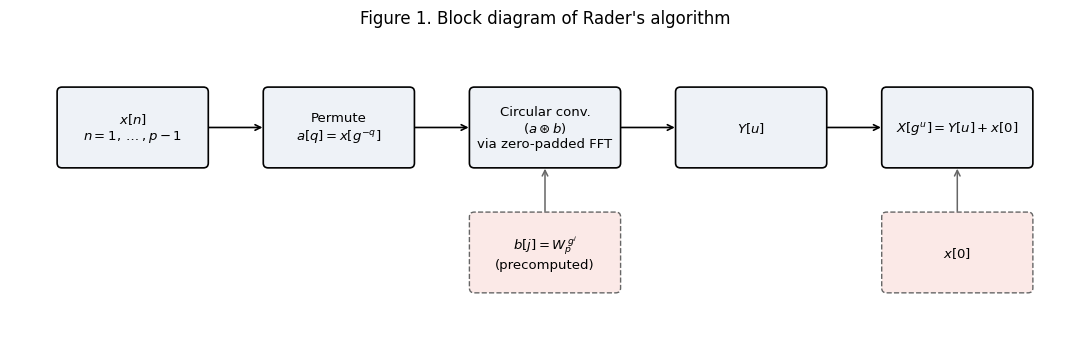

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_pipeline(ax, boxes, y=0.0, box_w=1.5, box_h=0.8, gap=0.6, fontsize=9.5):
    xs = []
    x = 0.0
    for label in boxes:
        rect = mpatches.FancyBboxPatch((x, y), box_w, box_h,
                                        boxstyle="round,pad=0.02,rounding_size=0.05",
                                        linewidth=1.2, edgecolor='black', facecolor='#eef2f7')
        ax.add_patch(rect)
        ax.text(x + box_w/2, y + box_h/2, label, ha='center', va='center', fontsize=fontsize)
        xs.append(x)
        x += box_w + gap
    for x0 in xs[:-1]:
        ax.annotate("", xy=(x0 + box_w + gap, y + box_h/2), xytext=(x0 + box_w, y + box_h/2),
                    arrowprops=dict(arrowstyle="->", lw=1.2, color='black'))
    return xs, box_w, box_h

def side_input(ax, x_target_left, y_target, box_w, box_h, label, y_offset=-1.3, fontsize=9.5):
    x_box = x_target_left
    y_box = y_target + y_offset
    rect = mpatches.FancyBboxPatch((x_box, y_box), box_w, box_h,
                                    boxstyle="round,pad=0.02,rounding_size=0.05",
                                    linewidth=1.0, edgecolor='0.4', facecolor='#fbe9e7', linestyle='dashed')
    ax.add_patch(rect)
    ax.text(x_box + box_w/2, y_box + box_h/2, label, ha='center', va='center', fontsize=fontsize)
    ax.annotate("", xy=(x_box + box_w/2, y_target), xytext=(x_box + box_w/2, y_box + box_h),
                arrowprops=dict(arrowstyle="->", lw=1.1, color='0.4'))

fig, ax = plt.subplots(figsize=(11, 3.6))

boxes = [
    "$x[n]$\n$n=1,\\dots,p-1$",
    "Permute\n$a[q]=x[g^{-q}]$",
    "Circular conv.\n$(a\\circledast b)$\nvia zero-padded FFT",
    "$Y[u]$",
    "$X[g^{u}]=Y[u]+x[0]$",
]
xs, bw, bh = draw_pipeline(ax, boxes, y=0.6)
side_input(ax, xs[2], 0.6, bw, bh, "$b[j]=W_p^{\\,g^{j}}$\n(precomputed)")
side_input(ax, xs[4], 0.6, bw, bh, "$x[0]$")

ax.set_xlim(-0.5, xs[-1] + bw + 0.5)
ax.set_ylim(-1.2, 2.0)
ax.axis('off')
ax.set_title("Figure 1. Block diagram of Rader's algorithm", fontsize=12)
plt.tight_layout()
plt.show()


**Figure 1.** Computational structure of Rader's algorithm, Equations (13)–(14). The fixed sequence $b$ depends only on $p$ and is computed once; the circular convolution itself is realized via the zero-padded radix-2 FFT technique of Section 2.3. The output $X[g^u]$ is subsequently written to array position $g^u \bmod p$, and $X[0] = \sum_n x[n]$ is computed separately.

### 3.4 Implementation

In [4]:
def rader_fft(x):
    """Rader's algorithm for the DFT of prime length p, per Eqs. (13)-(14)."""
    x = np.asarray(x, dtype=complex)
    p = len(x)
    g = find_primitive_root(p)
    M = p - 1

    # gpow[q] = g^q mod p
    gpow = [1] * M
    for q in range(1, M):
        gpow[q] = (gpow[q - 1] * g) % p

    # ginv_pow[q] = g^{-q} mod p
    ginv = pow(g, -1, p)
    ginv_pow = [1] * M
    for q in range(1, M):
        ginv_pow[q] = (ginv_pow[q - 1] * ginv) % p

    a = np.array([x[ginv_pow[q]] for q in range(M)], dtype=complex)   # Eq. (13)
    Wp = np.exp(-2j * np.pi / p)
    b = np.array([Wp ** gpow[j] for j in range(M)], dtype=complex)    # Eq. (13)

    Y = circular_convolve_via_linear(a, b, M)                         # Eq. (14)

    X = np.zeros(p, dtype=complex)
    X[0] = np.sum(x)
    for u in range(M):
        X[gpow[u]] = Y[u] + x[0]
    return X


### 3.5 Numerical Verification

Rader's algorithm is verified against direct evaluation of Equation (1) and against NumPy's FFT, for several prime lengths.

In [5]:
def dft_direct(x):
    x = np.asarray(x, dtype=complex)
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x

np.random.seed(0)
print(f"{'p':>4} | {'max |direct - Rader|':>22} | {'max |direct - NumPy|':>22}")
for p in [5, 7, 11, 13, 17]:
    x = np.random.randn(p) + 1j * np.random.randn(p)
    X_direct = dft_direct(x)
    X_rader = rader_fft(x)
    X_numpy = np.fft.fft(x)
    print(f"{p:4d} | {np.max(np.abs(X_direct - X_rader)):22.3e} | {np.max(np.abs(X_direct - X_numpy)):22.3e}")


   p |   max |direct - Rader| |   max |direct - NumPy|
   5 |              1.777e-15 |              1.777e-15
   7 |              1.397e-14 |              1.370e-14
  11 |              1.581e-14 |              1.601e-14
  13 |              8.243e-15 |              7.536e-15
  17 |              6.554e-14 |              6.793e-14


The agreement, to within floating-point precision, confirms that the re-indexing of Equations (11)–(14) correctly reproduces the DFT.

## 4. Bluestein's Algorithm

### 4.1 The Chirp Identity

Rader's algorithm applies only when $N$ is prime. Bluestein's algorithm removes this restriction by means of the algebraic identity

$$
kn = \frac{k^2 + n^2 - (k-n)^2}{2}, \tag{15}
$$

which holds for all integers $k,n$, regardless of any structure on $N$. Substituting Equation (15) into the exponent of Equation (1),

$$
W_N^{kn} = e^{-i\frac{2\pi}{N}kn} = e^{-i\frac{\pi}{N}k^2}\; e^{-i\frac{\pi}{N}n^2}\; e^{\,i\frac{\pi}{N}(k-n)^2}. \tag{16}
$$

### 4.2 Reduction to a Linear Convolution

Substituting Equation (16) into Equation (1) and separating the factors that depend on $k$ alone, $n$ alone, and $k-n$,

$$
X[k] = e^{-i\pi k^2/N} \sum_{n=0}^{N-1} \Big[x[n]\, e^{-i\pi n^2/N}\Big] \, e^{\,i\pi (k-n)^2/N}. \tag{17}
$$

Define the **down-chirp**–modulated input and the **up-chirp** kernel,

$$
a[n] \triangleq x[n]\, e^{-i\pi n^2/N}, \quad n = 0,\dots,N-1, \qquad
c[m] \triangleq e^{\,i\pi m^2/N}, \quad m = -(N-1), \dots, N-1. \tag{18}
$$

Equation (17) becomes

$$
X[k] = e^{-i\pi k^2/N} \sum_{n=0}^{N-1} a[n]\, c[k-n] = e^{-i\pi k^2/N}\,(a * c)[k], \qquad k = 0, \dots, N-1, \tag{19}
$$

where $a * c$ denotes the **linear** convolution of Equation (2) (not a circular convolution, in contrast to Rader's algorithm). Since $a$ has length $N$ and $c$ has length $2N-1$, the linear convolution has length $3N-2$, of which only the $N$ values at lags $k = 0,\dots,N-1$ — corresponding to indices $N-1,\dots,2N-2$ of the convolution array, given the offset introduced by $c$'s domain — are required. No assumption on $N$ was used in this derivation: Equation (19) holds for arbitrary $N$, prime or composite.

### 4.3 Block Diagram

Figure 2 summarizes the resulting computation: the input is modulated by a down-chirp, convolved linearly with a fixed up-chirp kernel (again via the zero-padded FFT technique of Section 2.3), and the relevant output lags are extracted and modulated by the same chirp a second time.

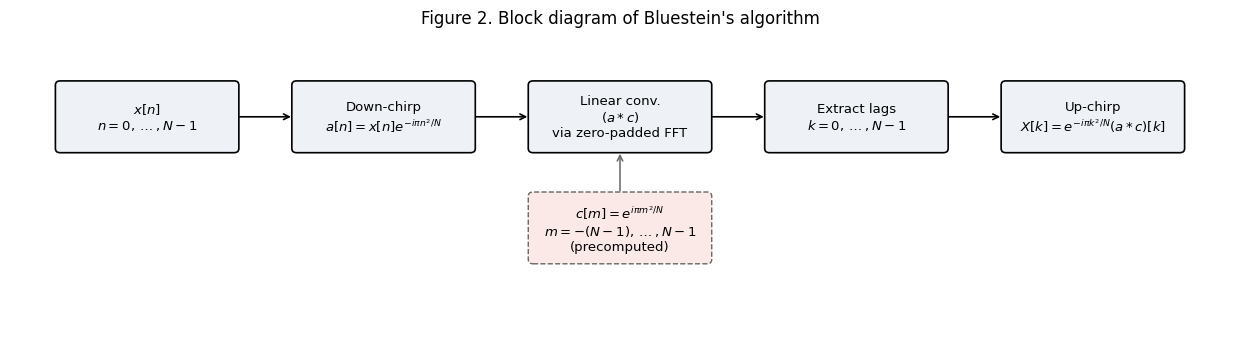

In [6]:
fig, ax = plt.subplots(figsize=(12.5, 3.6))

boxes2 = [
    "$x[n]$\n$n=0,\\dots,N-1$",
    "Down-chirp\n$a[n]=x[n]e^{-i\\pi n^2/N}$",
    "Linear conv.\n$(a*c)$\nvia zero-padded FFT",
    "Extract lags\n$k=0,\\dots,N-1$",
    "Up-chirp\n$X[k]=e^{-i\\pi k^2/N}(a*c)[k]$",
]
xs2, bw2, bh2 = draw_pipeline(ax, boxes2, y=0.6, box_w=1.9)
side_input(ax, xs2[2], 0.6, bw2, bh2, "$c[m]=e^{i\\pi m^2/N}$\n$m=-(N-1),\\dots,N-1$\n(precomputed)")

ax.set_xlim(-0.5, xs2[-1] + bw2 + 0.5)
ax.set_ylim(-1.6, 2.0)
ax.axis('off')
ax.set_title("Figure 2. Block diagram of Bluestein's algorithm", fontsize=12)
plt.tight_layout()
plt.show()


**Figure 2.** Computational structure of Bluestein's algorithm, Equations (18)–(19). Unlike Rader's algorithm, the convolution is linear rather than circular, and the derivation places no restriction on $N$.

### 4.4 Implementation

In [7]:
def bluestein_fft(x):
    """Bluestein's (chirp z-transform) algorithm for the DFT of arbitrary length N,
    per Eqs. (18)-(19)."""
    x = np.asarray(x, dtype=complex)
    N = len(x)

    n = np.arange(N)
    chirp = np.exp(-1j * np.pi * (n ** 2) / N)      # e^{-i pi n^2 / N}, Eq. (18)
    a = x * chirp

    m = np.arange(-(N - 1), N)
    c = np.exp(1j * np.pi * (m ** 2) / N)           # e^{i pi m^2 / N}, Eq. (18)

    conv = fast_linear_convolve(a, c)               # Eq. (19)

    offset = N - 1   # index of lag k=0 within conv, since c starts at m=-(N-1)
    X = chirp * conv[offset:offset + N]             # Eq. (19)
    return X


### 4.5 Numerical Verification

Bluestein's algorithm is verified for prime, composite, and power-of-two lengths alike, confirming that Equation (19) imposes no restriction on $N$.

In [8]:
print(f"{'N':>4} | {'factorization':>14} | {'max |direct - Bluestein|':>26} | {'max |direct - NumPy|':>22}")
for N in [5, 6, 8, 12, 13, 17]:
    x = np.random.randn(N) + 1j * np.random.randn(N)
    X_direct = dft_direct(x)
    X_blue = bluestein_fft(x)
    X_numpy = np.fft.fft(x)
    tag = "prime" if N in (5, 13, 17) else ("power of 2" if N & (N - 1) == 0 else "composite")
    print(f"{N:4d} | {tag:>14} | {np.max(np.abs(X_direct - X_blue)):26.3e} | {np.max(np.abs(X_direct - X_numpy)):22.3e}")


   N |  factorization |   max |direct - Bluestein| |   max |direct - NumPy|
   5 |          prime |                  8.882e-16 |              2.264e-15
   6 |      composite |                  2.722e-15 |              6.621e-15
   8 |     power of 2 |                  5.564e-15 |              4.463e-15
  12 |      composite |                  3.872e-14 |              4.189e-14
  13 |          prime |                  1.923e-14 |              9.669e-15
  17 |          prime |                  4.013e-14 |              3.913e-14


In every case, agreement is obtained to within floating-point precision, regardless of whether $N$ is prime, composite, or a power of two.

## 5. Comparison and Discussion

Both algorithms reduce a length-$N$ DFT to a convolution evaluable in $O(N\log_2 N)$ time via the zero-padded radix-2 FFT of Section 2.3, but they differ in scope and in the nature of the convolution produced.

| Property | Rader's algorithm | Bluestein's algorithm |
|---|---|---|
| Applicable lengths | Prime $N=p$ only | Arbitrary $N$ |
| Convolution type | Circular, length $p-1$ | Linear, length $\approx 2N$ |
| Auxiliary sequence | $b[j]=W_p^{g^j}$ (depends on $p$, $g$) | $c[m]=e^{i\pi m^2/N}$ (depends on $N$ only) |
| Key structure exploited | Cyclic group $(\mathbb{Z}/p\mathbb{Z})^{\times}$ | Quadratic identity, Eq. (15) |
| Requires primitive root | Yes | No |

In practice, Bluestein's algorithm is the more generally applicable of the two, since it places no number-theoretic restriction on $N$ and requires no primitive-root computation; it is the standard technique underlying general-length FFT routines for arbitrary $N$, including prime $N$. Rader's algorithm remains of interest both historically and because, for prime $N$, it produces a somewhat shorter convolution (length $p-1$ rather than $\approx 2p$) and exposes the underlying number-theoretic structure explicitly.

## 6. Conclusion

This notebook derived two classical extensions of the fast Fourier transform beyond the power-of-two, decimation-in-time setting of the companion notebook. Section 2.3 established the convolution theorem, Equation (5), and the zero-padding condition, Equation (8), that together allow any convolution to be evaluated in $O(L\log_2 L)$ time via the radix-2 FFT. Rader's algorithm (Section 3) was shown, via the substitution of Equation (11) into the DFT sum, to reduce a prime-length DFT to a circular convolution of length $p-1$, Equation (14). Bluestein's algorithm (Section 4) was shown, via the quadratic identity of Equation (15), to reduce a DFT of arbitrary length to a linear convolution, Equation (19). In both cases, the resulting convolution was evaluated using the zero-padded radix-2 FFT of Section 2.3, yielding an overall $O(N\log_2 N)$ algorithm applicable to prime, composite, and power-of-two lengths alike. Numerical verification in Sections 3.5 and 4.5 confirmed agreement with direct DFT evaluation and with the NumPy reference implementation to within floating-point precision.